# Téléchargement et Import 

In [1]:
from download_data import download_all
from preprocessing import prepare_var_dataset, load_market_data, clean_all_market_data
from data_vis import plot_all_returns, plot_returns_separately, plot_single_series, build_price_dataframe, plot_all_prices, plot_prices_separately
from test import adf_test_single_series, adf_test_all_var_series, print_adf_conclusion, build_var_stability_table, is_var_stable, print_var_stability_conclusion, residual_serial_correlation_test, get_residual_serial_correlation_summary, print_residual_serial_correlation_conclusion, get_granger_test_summary, granger_tests_for_gold, print_granger_conclusion
from modele import (
    rolling_var_lag_selection,
    choose_final_lag_from_rolling,
    lag_selection_frequency_table,
    print_final_lag_selection,
    fit_var3,
    get_var_summary,
    get_var_model_info,
    get_var_parameters,
    get_var_residuals,
    get_var_fitted_values,
    fit_var3_without_sp500,
)
import pandas as pd


download_all()

/Users/adrienferrand-bastet/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Téléchargement Yahoo Finance : gold (GC=F)
Enregistré : data/gold.csv
Téléchargement Yahoo Finance : dxy (DX-Y.NYB)
Enregistré : data/dxy.csv
Téléchargement Yahoo Finance : sp500 (^GSPC)
Enregistré : data/sp500.csv
Téléchargement Yahoo Finance : vix (^VIX)
Enregistré : data/vix.csv
Téléchargement CPI via FRED
URL CPI appelée : https://api.stlouisfed.org/fred/series/observations?series_id=CPIAUCSL&api_key=31da204ceab6c0f0deeb22ba69f9c488&file_type=json&observation_start=2005-01-01&observation_end=2026-04-16
Enregistré : data/cpi.csv
Téléchargement GPR
Fichier GPR détecté : https://www.matteoiacoviello.com/gpr_files/data_gpr_export.xls
Fichier brut enregistré : data/gpr_raw.xls
Téléchargement terminé.


# Préprocessing 

In [2]:
var_df = prepare_var_dataset(data_dir="data")

-> Ici on charge les csv, on nettoie les bdd pour avoir les mêmes colonnes, on applique le log aux returns de la série pour la stationarisé, on fusionne ensuite toutes les bdd avec date et enfin on enlève les NaN créer par les returns 

# Visualisation

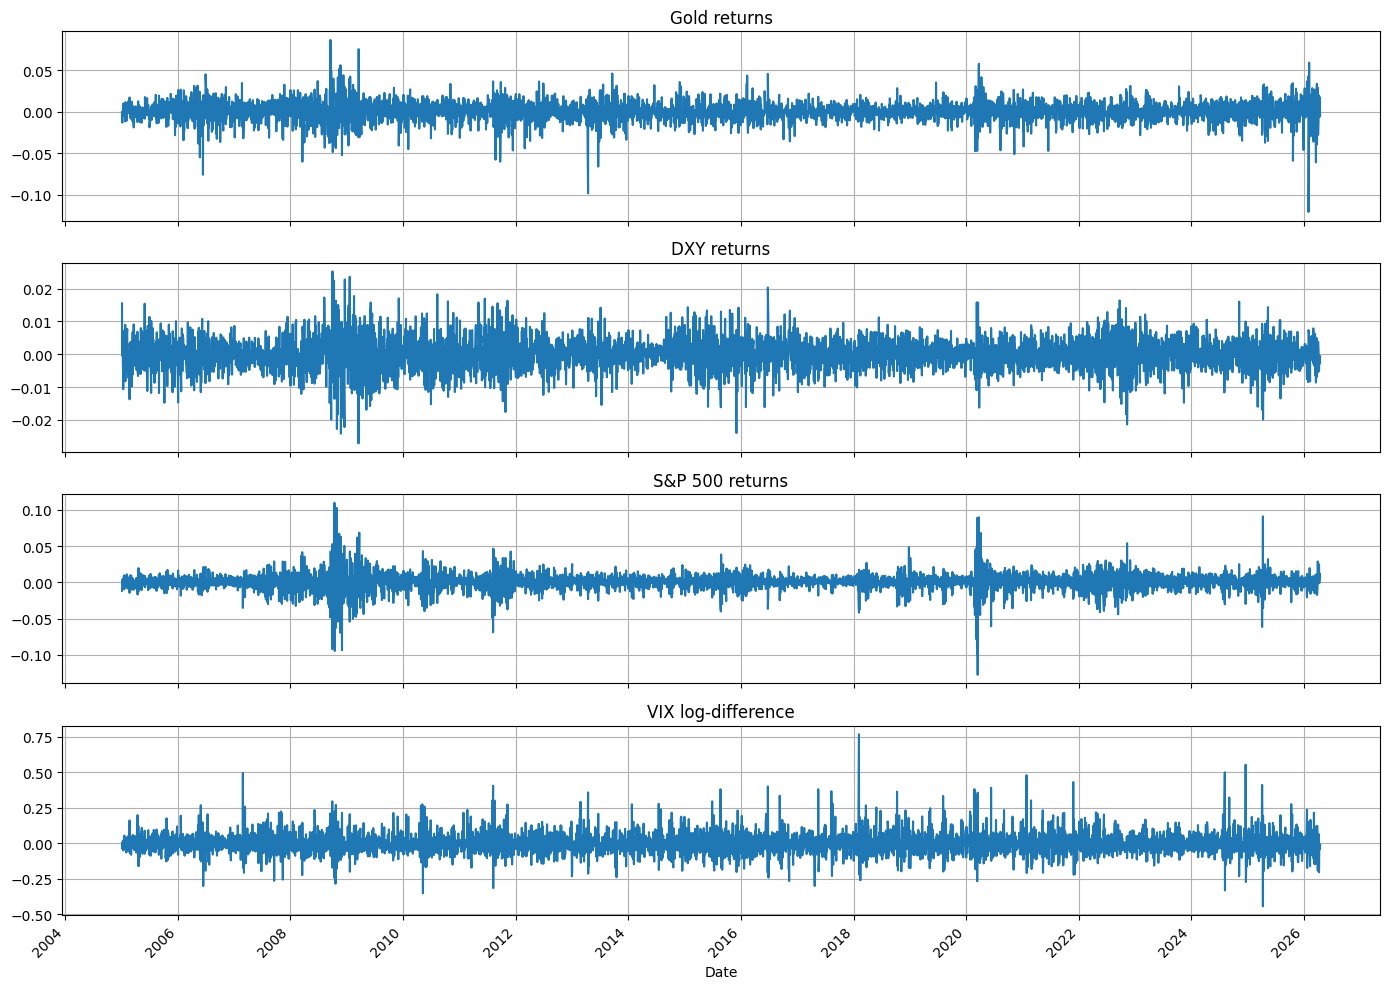

In [3]:
plot_returns_separately(var_df)

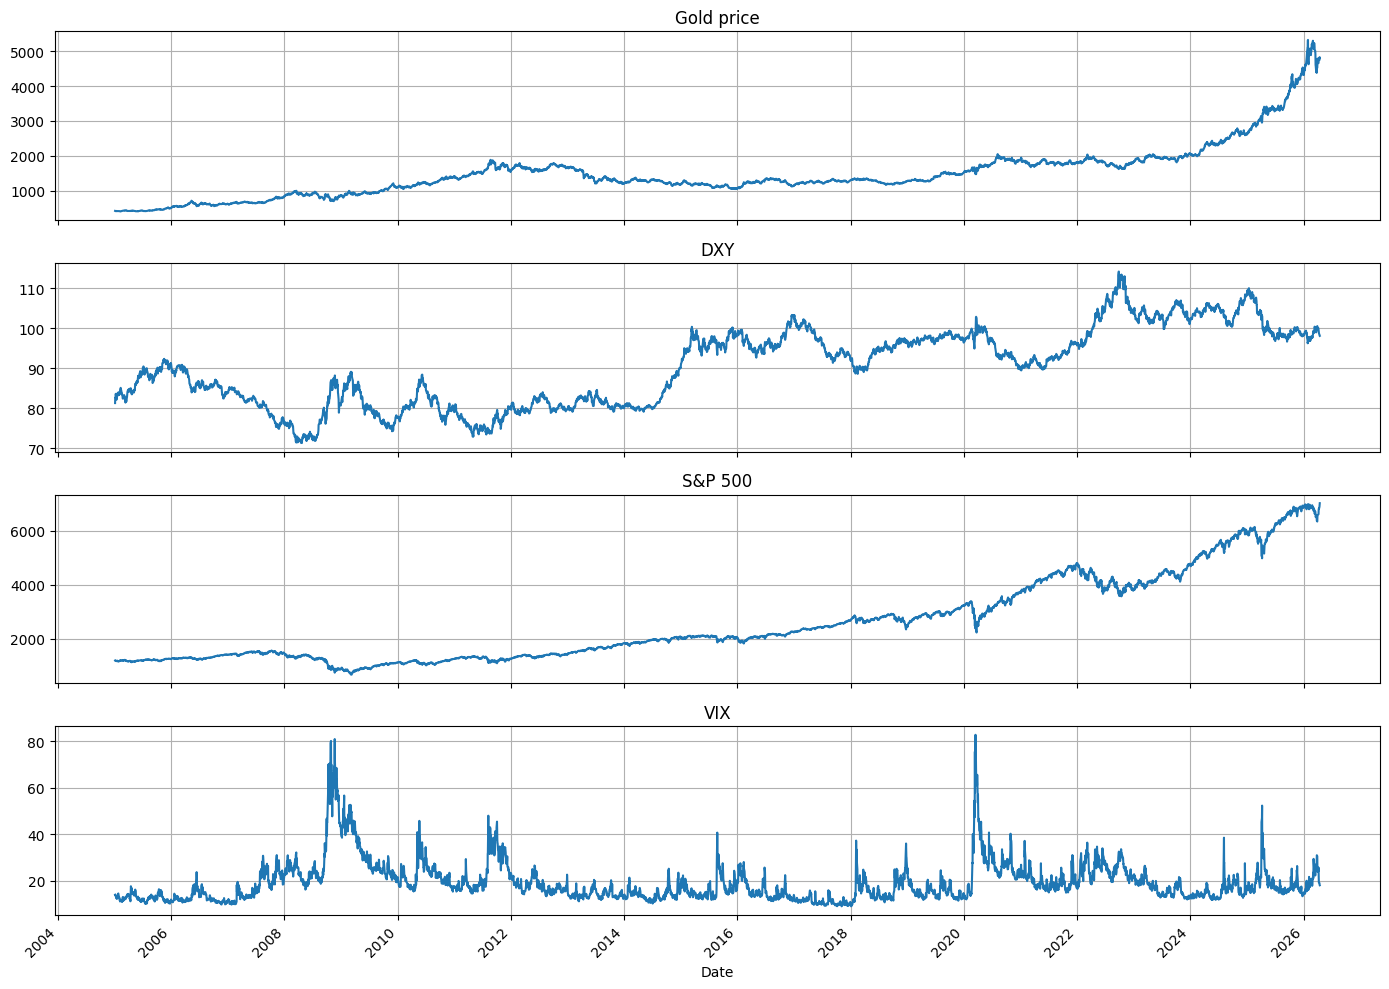

In [4]:
raw_data = load_market_data("data")
cleaned_data = clean_all_market_data(raw_data)
price_df = build_price_dataframe(cleaned_data)
plot_prices_separately(price_df)

# TEST sur les séries

Test ADF qui vérifie la stationarité des séries (returns)

In [5]:
adf_results = adf_test_all_var_series(var_df)
adf_results 

,series,adf_statistic,p_value,used_lags,n_obs,critical_value_1pct,critical_value_5pct,critical_value_10pct,stationary_5pct
0,gold_ret,-29.200022,0.000000e+00,6,5337,-3.431576,-2.862082,-2.567058,True
1,dxy_ret,-22.009662,0.000000e+00,10,5333,-3.431577,-2.862082,-2.567059,True
2,sp500_ret,-16.362146,2.863717e-29,19,5324,-3.431579,-2.862083,-2.567059,True
3,vix_ret,-29.411046,0.000000e+00,8,5335,-3.431576,-2.862082,-2.567058,True


On a donc des p-value > 0.05 donc l'ensemble des séries sont stationaires 

# Modélisation

Choix du lag du VAR. 
On va estimer des VAR avec des lags allant de 1 à 10 sur une fenêtre glissante de 7 ans d'écart et un déplacement de 2 ans à chaque fois. On calcule pour chaque VAR(p) le BIC et AIC sur la fenêtre et On regarde sur la fenetre et le lag ou les critères sont les plus bas. Ensuite on va fiare la moyenne des des lags les meilleures et arondir à l'entier le plus proche. 
L'idée est de choisir un nombre de retards qui reste raisonnablement pertinent à travers différentes périodes de marché. 

In [6]:
summary_df, criteria_dict = rolling_var_lag_selection(
    var_df=var_df,
    window_years=7,
    step_years=2,
    max_lag=10
)
summary_df

/Users/adrienferrand-bastet/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/adrienferrand-bastet/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/adrienferrand-bastet/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/adrienferrand-bastet/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provide

,window,start_date,end_date,n_obs,variables,best_lag_aic,best_aic,best_lag_bic,best_bic
0,window_1,2005-01-04,2012-01-04,1757,"gold_ret, dxy_ret, sp500_ret, vix_ret",3,-33.960173,1,-33.878892
1,window_2,2007-01-04,2014-01-04,1763,"gold_ret, dxy_ret, sp500_ret, vix_ret",2,-33.891303,1,-33.812840
2,window_3,2009-01-04,2016-01-04,1761,"gold_ret, dxy_ret, sp500_ret, vix_ret",10,-34.833205,1,-34.736760
3,window_4,2011-01-04,2018-01-04,1760,"gold_ret, dxy_ret, sp500_ret, vix_ret",2,-35.697520,1,-35.631314
4,window_5,2013-01-04,2020-01-04,1759,"gold_ret, dxy_ret, sp500_ret, vix_ret",1,-36.321979,1,-36.259728
5,window_6,2015-01-04,2022-01-04,1760,"gold_ret, dxy_ret, sp500_ret, vix_ret",9,-35.387829,1,-35.173147
6,window_7,2017-01-04,2024-01-04,1760,"gold_ret, dxy_ret, sp500_ret, vix_ret",9,-35.384902,1,-35.222254
7,window_8,2019-01-04,2026-01-04,1759,"gold_ret, dxy_ret, sp500_ret, vix_ret",9,-35.034284,1,-34.894419


In [7]:
final_lag_dict = choose_final_lag_from_rolling(summary_df)
print_final_lag_selection(final_lag_dict)

Lags sélectionnés sur l'ensemble des fenêtres (AIC + BIC) :
[3, 2, 10, 2, 1, 9, 9, 9, 1, 1, 1, 1, 1, 1, 1, 1]

Moyenne des lags sélectionnés : 3.3125
Lag final retenu (arrondi) : 3


In [8]:
freq_table = lag_selection_frequency_table(summary_df)
freq_table

,lag,frequency
0,1,9
1,2,2
2,3,1
3,9,3
4,10,1


In [9]:
final_lag = final_lag_dict["final_lag"]
final_lag

3

In [10]:
var3_model = fit_var3(var_df)
var3_info = get_var_model_info(var3_model)
var3_params = get_var_parameters(var3_model)
var3_residuals = get_var_residuals(var3_model)
var3_fitted = get_var_fitted_values(var3_model)
var3_fitted.head()
var3_info
print(get_var_summary(var3_model))

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 16, Apr, 2026
Time:                     18:08:48
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                   -34.6014
Nobs:                     5341.00    HQIC:                  -34.6431
Log likelihood:           62312.1    FPE:                8.80957e-16
AIC:                     -34.6655    Det(Omega_mle):     8.72432e-16
--------------------------------------------------------------------
Results for equation gold_ret
                  coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------------
const                0.000467         0.000158            2.951           0.003
L1.gold_ret         -0.030094         0.014837           -2.028           0.043
L1.dxy_ret          -0.144002         0.037001           -3.8

/Users/adrienferrand-bastet/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/adrienferrand-bastet/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/vector_ar/var_model.py:1501: RuntimeWarning: divide by zero encountered in matmul
  return np.kron(np.linalg.inv(z.T @ z), self.sigma_u)
/Users/adrienferrand-bastet/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/vector_ar/var_model.py:1501: RuntimeWarning: overflow encountered in matmul
  return np.kron(np.linalg.inv(z.T @ z), self.sigma_u)
/Users/adrienferrand-bastet/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/vector_ar/var_model.py:1501: RuntimeWarning: invalid value encountered in matmul
  return np.kron(np.linalg.inv(z.T @ z), self.sigma_u)


L’équation des rendements de l’or met surtout en évidence un rôle significatif du dollar à court terme, avec un effet négatif du premier retard du rendement du DXY sur le rendement de l’or. Ce résultat est économiquement cohérent. Le premier retard du VIX apparaît également significatif, bien que son signe négatif suggère une relation plus complexe que la simple interprétation de l’or comme actif refuge à très court terme. En revanche, les retards du S&P 500 n’apparaissent pas significatifs dans l’équation de l’or. Ces résultats suggèrent que, dans la dynamique journalière de l’or, le dollar joue un rôle plus directement prédictif que le marché actions.

# Test sur le VAR

TEST de la stabilité du VAR 

In [11]:
stability_table = build_var_stability_table(var3_model)
stability_table
print_var_stability_conclusion(var3_model)

Test de stabilité du VAR
------------------------
Le modèle est-il stable ? True
Conclusion : toutes les racines sont à l'extérieur du cercle unité.
Le VAR peut être considéré comme stable.


Le VAR est donc stable 

TEST d'autocorrélation des résidus 

In [12]:
whiteness_test = residual_serial_correlation_test(var3_model, nlags=12)
print(whiteness_test)
whiteness_summary = get_residual_serial_correlation_summary(var3_model, nlags=12)
whiteness_summary
print_residual_serial_correlation_conclusion(var3_model, nlags=12)

<statsmodels.tsa.vector_ar.hypothesis_test_results.WhitenessTestResults object. H_0: residual autocorrelation up to lag 12 is zero: reject at 5% significance level. Test statistic: 392.880, critical value: 173.004>, p-value: 0.000>
Test d'autocorrélation des résidus (Portmanteau)
------------------------------------------------
Nombre de lags testés : 12
Statistique de test : 392.880069
Valeur critique : 173.004059
p-value : 0.000000
Degrés de liberté : 144
Conclusion : on rejette l'hypothèse nulle au seuil de 5%.
Les résidus présentent encore de l'autocorrélation.


Bien que le VAR(3) soit stable, le test de Portmanteau rejette nettement l’hypothèse d’absence d’autocorrélation résiduelle. Cela suggère que la structure dynamique du système n’est pas entièrement capturée par trois retards

TEST de causalité de granger 

In [13]:
granger_gold_df = granger_tests_for_gold(var3_model)
granger_gold_df

/Users/adrienferrand-bastet/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/vector_ar/var_model.py:2003: RuntimeWarning: divide by zero encountered in matmul
  middle = np.linalg.inv(C @ self.cov_params() @ C.T)
/Users/adrienferrand-bastet/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/vector_ar/var_model.py:2003: RuntimeWarning: overflow encountered in matmul
  middle = np.linalg.inv(C @ self.cov_params() @ C.T)
/Users/adrienferrand-bastet/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/vector_ar/var_model.py:2003: RuntimeWarning: invalid value encountered in matmul
  middle = np.linalg.inv(C @ self.cov_params() @ C.T)


,caused,causing,test_statistic,p_value,df,reject_h0_5pct
0,gold_ret,dxy_ret,5.959863,0.000467,"(3, 21312)",True
1,gold_ret,sp500_ret,1.511801,0.209187,"(3, 21312)",False
2,gold_ret,vix_ret,4.004126,0.007351,"(3, 21312)",True


Ainsi, à fréquence journalière, les variations du dollar et du stress de marché contiennent de l’information utile pour prévoir l’or, davantage que les rendements actions eux-mêmes.

Estimation d'un VAR(3) sans le sp500

In [14]:
var3_no_sp500_model = fit_var3_without_sp500(var_df)
print(get_var_summary(var3_no_sp500_model))
var3_no_sp500_info = get_var_model_info(var3_no_sp500_model)
var3_no_sp500_info

/Users/adrienferrand-bastet/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/adrienferrand-bastet/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/vector_ar/var_model.py:1501: RuntimeWarning: divide by zero encountered in matmul
  return np.kron(np.linalg.inv(z.T @ z), self.sigma_u)
/Users/adrienferrand-bastet/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/vector_ar/var_model.py:1501: RuntimeWarning: overflow encountered in matmul
  return np.kron(np.linalg.inv(z.T @ z), self.sigma_u)
/Users/adrienferrand-bastet/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/vector_ar/var_model.py:1501: RuntimeWarning: invalid value encountered in matmul
  return np.kron(np.linalg.inv(z.T @ z), self.sigma_u)


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 16, Apr, 2026
Time:                     18:08:48
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -24.9293
Nobs:                     5341.00    HQIC:                  -24.9534
Log likelihood:           43966.9    FPE:                1.43638e-11
AIC:                     -24.9663    Det(Omega_mle):     1.42835e-11
--------------------------------------------------------------------
Results for equation gold_ret
                 coefficient       std. error           t-stat            prob
------------------------------------------------------------------------------
const               0.000468         0.000158            2.965           0.003
L1.gold_ret        -0.031892         0.014801           -2.155           0.031
L1.dxy_ret         -0.150519         0.036061           -4.174   

{'lag_order': 3,
 'n_obs': 5341,
 'n_equations': 3,
 'aic': np.float64(-24.966307915618096),
 'bic': np.float64(-24.929330749280297),
 'hqic': np.float64(-24.953391198556147),
 'fpe': np.float64(1.436382960193512e-11),
 'variables': ['gold_ret', 'dxy_ret', 'vix_ret']}

Le VAR sans S&P 500 paraît préférable. Il garde les effets les plus utiles pour l’or : L1.dxy_ret = -0.1505 avec p < 0.001, donc le dollar reste un déterminant fort, et le VIX reste aussi informatif avec L1.vix_ret = -0.0080 (p < 0.001) et L3.vix_ret = 0.0043 (p = 0.040). À l’inverse, dans le modèle précédent, le S&P 500 n’était ni significatif dans l’équation de l’or ni prédictif au sens de Granger (p = 0.209). En plus, retirer le S&P 500 réduit la redondance du système : la forte corrélation résiduelle sp500_ret / vix_ret de -0.740 disparaît. Le modèle à 3 variables est donc plus parcimonieux, plus lisible, et plus défendable pour expliquer l’or. Il faut maintenant confirmer cela avec les diagnostics, surtout l’autocorrélation résiduelle.

In [15]:
print_var_stability_conclusion(var3_no_sp500_model)

Test de stabilité du VAR
------------------------
Le modèle est-il stable ? True
Conclusion : toutes les racines sont à l'extérieur du cercle unité.
Le VAR peut être considéré comme stable.


In [18]:
whiteness_summary_no_sp500 = get_residual_serial_correlation_summary(var3_no_sp500_model, nlags=12)
whiteness_summary_no_sp500
whiteness_test_no_sp500 = residual_serial_correlation_test(var3_no_sp500_model, nlags=12)
print(whiteness_test_no_sp500)

<statsmodels.tsa.vector_ar.hypothesis_test_results.WhitenessTestResults object. H_0: residual autocorrelation up to lag 12 is zero: reject at 5% significance level. Test statistic: 199.827, critical value: 103.010>, p-value: 0.000>


In [20]:
granger_dxy_gold_no_sp500 = get_granger_test_summary(
    fitted_model=var3_no_sp500_model,
    caused="gold_ret",
    causing="dxy_ret"
)

granger_vix_gold_no_sp500 = get_granger_test_summary(
    fitted_model=var3_no_sp500_model,
    caused="gold_ret",
    causing="vix_ret"
)

print_granger_conclusion(granger_dxy_gold_no_sp500)
print_granger_conclusion(granger_vix_gold_no_sp500)

Test de causalité de Granger
----------------------------
Variable expliquée : gold_ret
Variable testée : dxy_ret
Statistique de test : 6.897322
p-value : 0.000123
Degrés de liberté : (3, 15993)
Conclusion : on rejette l'hypothèse nulle au seuil de 5%.
La variable testée Granger-cause la variable expliquée.
Test de causalité de Granger
----------------------------
Variable expliquée : gold_ret
Variable testée : vix_ret
Statistique de test : 6.715272
p-value : 0.000159
Degrés de liberté : (3, 15993)
Conclusion : on rejette l'hypothèse nulle au seuil de 5%.
La variable testée Granger-cause la variable expliquée.


Le retrait du S&P 500 améliore la qualité du VAR et confirme que les déterminants les plus utiles pour l’or sont le dollar et le VIX. En revanche, le test de whiteness restant rejeté, le modèle à 3 variables ne constitue pas encore une spécification pleinement satisfaisante du point de vue dynamique.
